# MorphEO WP1.3: Reference data collection

## Testing openEO

In [26]:
import openeo
import json
import shapely.geometry
import folium
import webbrowser
import os
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd

In [2]:
out_dir = '../data/output'

In [3]:
# connect to openeo
conn = openeo.connect("https://openeo.dataspace.copernicus.eu/openeo/1.2").authenticate_oidc()

Authenticated using refresh token.


## Exploring glacial lake and lava flow datasets for Iceland

### Glacial lake data

#### Little practice with NDWI

In [4]:
# define aoi
jok_aoi = json.load(open('../data/preliminary/jokulsarlon_aoi.geojson'))
region = jok_aoi['features'][0]['geometry']
geom = shapely.geometry.shape(region)

In [5]:
# define time period
time_period = ['2023-07-01', '2023-07-31']

In [6]:
s2 = conn.load_collection(
    'SENTINEL2_L1C',
    spatial_extent=geom,
    temporal_extent=time_period,
    bands=["B02", "B03", "B04", "B08"]
)

In [7]:
# Calculate NDWI
green = s2.band('B03')
nir = s2.band('B08')
ndwi = (green - nir) / (green + nir)
ndwi.mask_polygon(mask=geom)

In [8]:
# Download the result
#ndwi.download(os.path.join(out_dir, 'ndwi.nc'))

<xarray.Dataset> Size: 222MB
Dimensions:  (t: 18, x: 1532, y: 2010)
Coordinates:
  * t        (t) datetime64[ns] 144B 2023-07-02 2023-07-04 ... 2023-07-30
  * x        (x) float64 12kB 4.297e+05 4.297e+05 ... 4.45e+05 4.45e+05
  * y        (y) float64 16kB 7.115e+06 7.115e+06 ... 7.095e+06 7.095e+06
Data variables:
    crs      |S1 1B ...
    var      (t, y, x) float32 222MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform


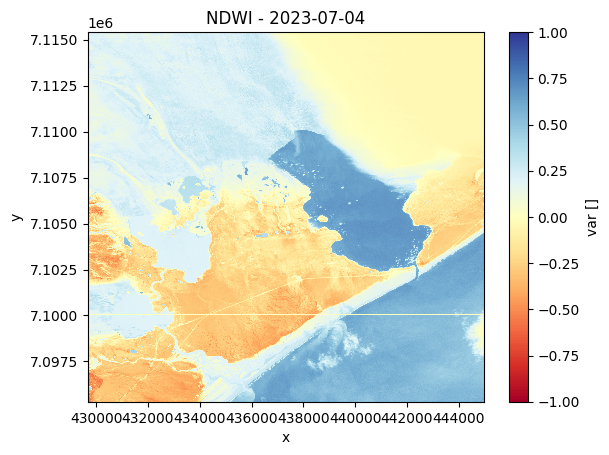

In [9]:
# save png
ndwi_ds = xr.open_dataset('../data/output/ndwi.nc')

print(ndwi_ds)
ndwi_data = ndwi_ds['var'].isel(t=9)

fig, ax = plt.subplots()
ndwi_data.plot(cmap='RdYlBu', vmin=-1, vmax=1)
plt.title(f"NDWI - {str(ndwi_ds['t'].values[1])[:10]}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.savefig('../data/output/ndwi.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()



### Lava flow data

In [10]:
# define aoi
f_aoi = json.load(open('../data/preliminary/fagradalsfjall_aoi.geojson'))
f_region = f_aoi['features'][0]['geometry']
f_geom = shapely.geometry.shape(f_region)

In [11]:
# define time period
time_period = ['2022-08-01', '2022-08-31']

In [12]:
s2 = conn.load_collection(
    'SENTINEL2_L1C',
    spatial_extent=f_geom,
    temporal_extent=time_period,
    bands=["B08", "B11"]
)

Normalized Hotspot Index (Falconieri et al 2022, https://doi.org/10.3390/rs14215481)

In [13]:
nir = s2.band("B08")
swir1 = s2.band("B11")
nhi = (swir1 - nir) / (swir1 + nir)
nhi.mask_polygon(mask=f_geom)


In [14]:
# Download the result
nhi.download(os.path.join(out_dir, 'nhi.nc'))

<xarray.Dataset> Size: 112MB
Dimensions:  (t: 18, x: 1305, y: 1190)
Coordinates:
  * t        (t) datetime64[ns] 144B 2022-08-02 2022-08-03 ... 2022-08-30
  * x        (x) float64 10kB 4.279e+05 4.279e+05 ... 4.41e+05 4.41e+05
  * y        (y) float64 10kB 7.089e+06 7.089e+06 ... 7.077e+06 7.077e+06
Data variables:
    crs      |S1 1B ...
    var      (t, y, x) float32 112MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform


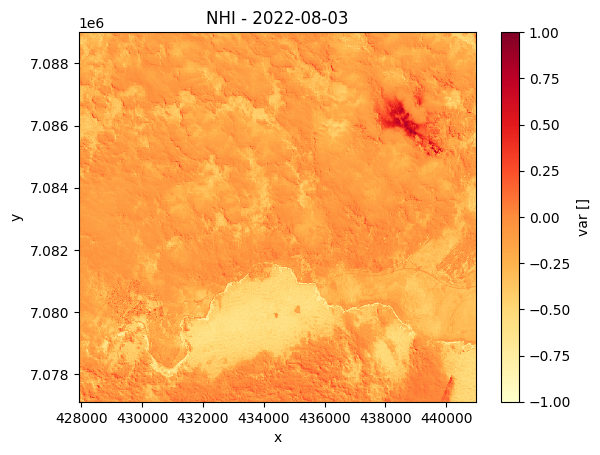

In [24]:
# save png
nhi_ds = xr.open_dataset('../data/output/nhi.nc')

print(nhi_ds)
nhi_data = nhi_ds['var'].isel(t=5)

fig, ax = plt.subplots()
nhi_data.plot(cmap='YlOrRd', vmin=-1, vmax=1)
plt.title(f"NHI - {str(nhi_ds['t'].values[1])[:10]}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.savefig('../data/output/nhi.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()



In [32]:
# add lava outline from same date
gdf = gpd.read_file("../data/preliminary/lava_outline_20220803_1705_A6D_Gunnarson_et_al2023.gpkg")
gdf = gdf.set_crs("EPSG:3057", allow_override=True)

# Convert to EPSG:4326
gdf_4326 = gdf.to_crs("EPSG:4326")
polygon = gdf_4326.geometry.iloc[0]  

<xarray.Dataset> Size: 112MB
Dimensions:  (t: 18, x: 1305, y: 1190)
Coordinates:
  * t        (t) datetime64[ns] 144B 2022-08-02 2022-08-03 ... 2022-08-30
  * x        (x) float64 10kB 4.279e+05 4.279e+05 ... 4.41e+05 4.41e+05
  * y        (y) float64 10kB 7.089e+06 7.089e+06 ... 7.077e+06 7.077e+06
Data variables:
    crs      |S1 1B ...
    var      (t, y, x) float32 112MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform


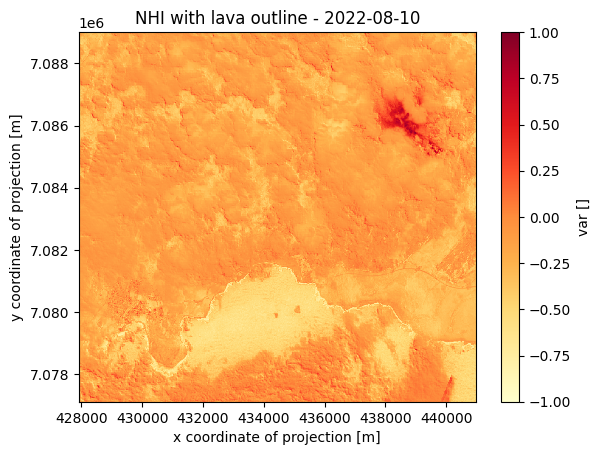

In [33]:
nhi_ds = xr.open_dataset('../data/output/nhi.nc')

print(nhi_ds)
nhi_data = nhi_ds['var'].isel(t=5)

fig, ax = plt.subplots()
nhi_data.plot(cmap='YlOrRd', vmin=-1, vmax=1)
x, y = polygon.exterior.xy
ax.plot(x, y, color='black', linewidth=3)  # overlay polygon

plt.title(f"NHI with lava outline - {str(nhi_ds['t'].values[5])[:10]}")
plt.savefig('../data/output/nhi_lava_outline_20220803.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()